In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd

%matplotlib widget
import matplotlib.pyplot as plt




def find_project_root(start=Path.cwd()):
    """
    Walk upward until we find a project root marker.
    """
    markers = [".git", "pyproject.toml", "setup.py"]

    current = start.resolve()

    while current != current.parent:
        for marker in markers:
            if (current / marker).exists():
                return current
        current = current.parent

    raise RuntimeError("Project root not found")


PROJECT_ROOT = find_project_root()

EXPERIMENT_DIR = PROJECT_ROOT / "data" / "experiments"
SETTINGS_DIR = EXPERIMENT_DIR / "settings"


def load_experiment(run_id):
    matches = [p for p in EXPERIMENT_DIR.iterdir() if p.is_dir() and run_id in p.name]

    if not matches:
        raise RuntimeError(f"No experiment found for run_id '{run_id}'")

    if len(matches) > 1:
        raise RuntimeError(f"Multiple matches for run_id '{run_id}'")

    exp_dir = matches[0]

    # extract settings hash from folder name
    settings_hash = exp_dir.name.split("__")[1]

    csv_path = exp_dir / "experiment_data.csv"
    params_path = SETTINGS_DIR / settings_hash / "params.json"

    df = pd.read_csv(csv_path)

    with open(params_path) as f:
        params = json.load(f)

    return df, params, exp_dir

In [ ]:
run_ids = [
    "20260306_130730",
    "20260306_131709"
]

dfs = {}
params_dict = {}

for run_id in run_ids:
    df, params, path = load_experiment(run_id)

    dfs[run_id] = df
    params_dict[run_id] = params

    
for run_id, params in params_dict.items():
    print(f"\n=== Parameters for run {run_id} ===")
    
    for k, v in params.items():
        display(f"{k:25s}: {v}")


=== Parameters for run 20260306_130730 ===
axial_cutting_depth_mm   : 1.0
dt                       : 1e-05
feed_per_tooth_mm        : 0.14400000000000002
feed_speed_mm_s          : 20.0
frequency_hz             : 138.88888888888889
omega_rad_s              : -872.6646259971648
period                   : 0.007200000000000001
rev_per_s                : 138.88888888888889
rpm                      : 8333.333333333334
samples_per_period       : 720
spindle_spin             : -1
tool_diameter_mm         : 20.0
tool_radius_mm           : 10.0
z_teeth                  : 1

=== Parameters for run 20260306_131709 ===
axial_cutting_depth_mm   : 1.0
dt                       : 1e-05
feed_per_tooth_mm        : 0.036000000000000004
feed_speed_mm_s          : 20.0
frequency_hz             : 138.88888888888889
omega_rad_s              : -872.6646259971648
period                   : 0.007200000000000001
rev_per_s                : 138.88888888888889
rpm                      : 8333.333333333334
samples_p

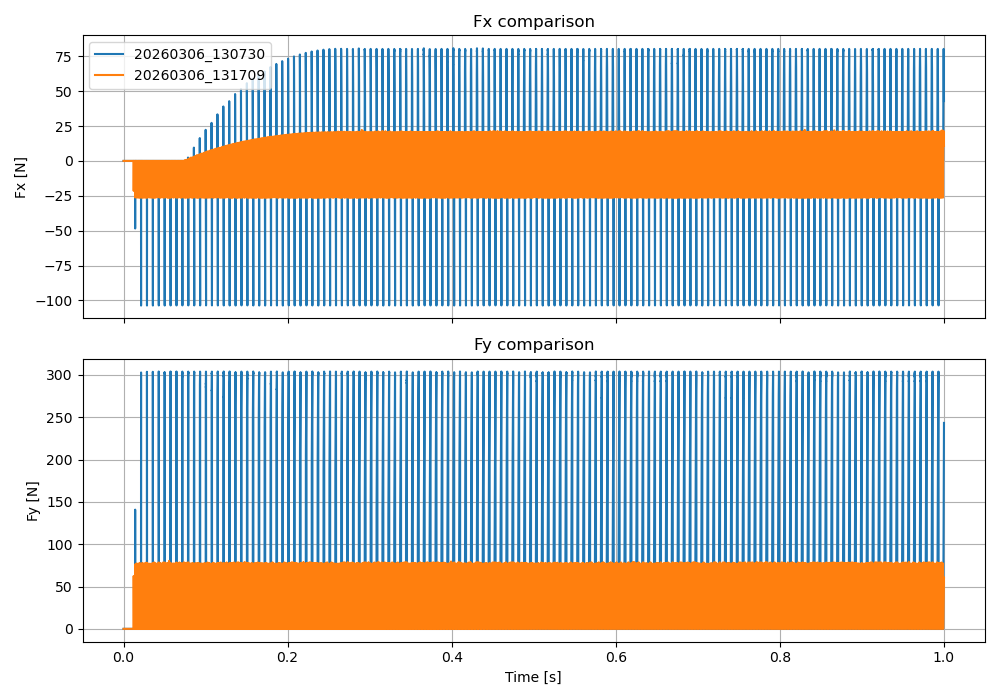

In [3]:
fig, ax = plt.subplots(2,1, figsize=(10,7), sharex=True)

for run_id, df in dfs.items():

    t = df["time_s"]

    ax[0].plot(t, df["fmill_x_N"], label=run_id)
    ax[1].plot(t, df["fmill_y_N"], label=run_id)

ax[0].set_ylabel("Fx [N]")
ax[0].set_title("Fx comparison")
ax[0].grid()
ax[0].legend()

ax[1].set_ylabel("Fy [N]")
ax[1].set_xlabel("Time [s]")
ax[1].set_title("Fy comparison")
ax[1].grid()

plt.tight_layout()

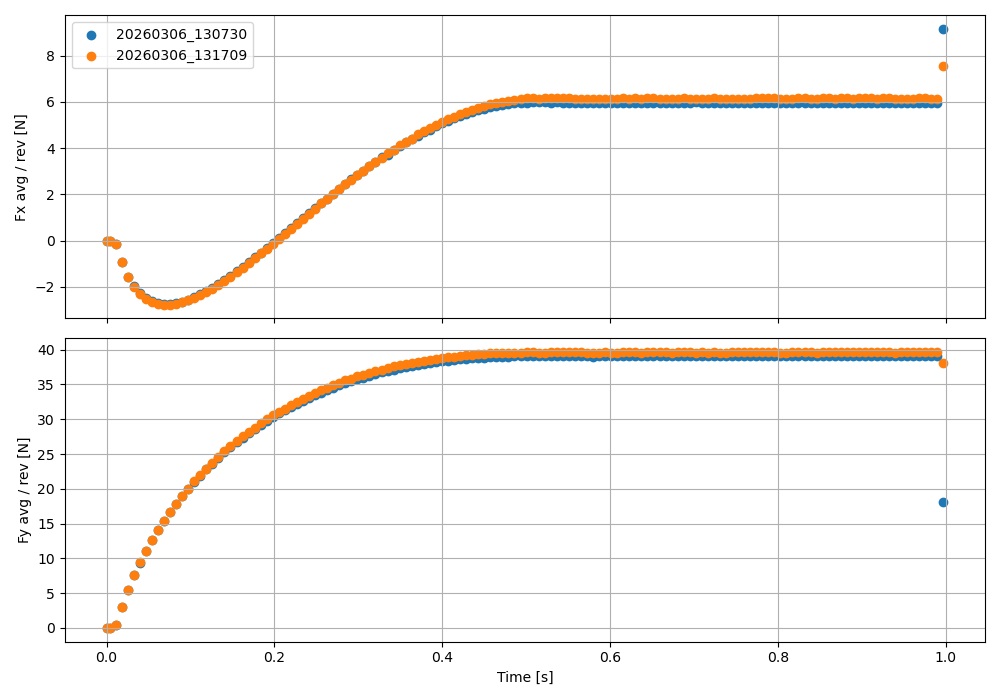

In [4]:
fig, ax = plt.subplots(2,1, figsize=(10,7), sharex=True)

for run_id, df in dfs.items():

    t = df["time_s"].to_numpy()
    phi = df["tool_orientation"].to_numpy()

    fx = df["fmill_x_N"].to_numpy()
    fy = df["fmill_y_N"].to_numpy()

    phi_unwrapped = np.unwrap(phi)
    rev_idx = np.floor((phi_unwrapped - phi_unwrapped[0]) / (2*np.pi)).astype(int)

    df_rev = pd.DataFrame({
        "time_s": t,
        "rev_idx": rev_idx,
        "fx": fx,
        "fy": fy,
    })

    df_rev_avg = df_rev.groupby("rev_idx").mean().reset_index()

    ax[0].scatter(df_rev_avg["time_s"], df_rev_avg["fx"], label=run_id)
    ax[1].scatter(df_rev_avg["time_s"], df_rev_avg["fy"], label=run_id)

ax[0].set_ylabel("Fx avg / rev [N]")
ax[0].grid()
ax[0].legend()

ax[1].set_ylabel("Fy avg / rev [N]")
ax[1].set_xlabel("Time [s]")
ax[1].grid()

plt.tight_layout()